<a href="https://colab.research.google.com/github/AartiP87/part-4-ai-solution-design-/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 4: AI Solution Design — Healthcare Medical Image Triage

**Domain:** Healthcare  
**Problem:** Automated chest X-ray triage to support radiologists  
**AI Task:** Image Classification  
**Model:** DenseNet-121 (Transfer Learning)

---

This notebook supports the solution design with:
- Reference data exploration from the provided CSVs
- Business KPI analysis and visualisation
- Model architecture summary
- Evaluation framework
- Responsible AI risk matrix

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Markdown

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Reference Data

In [4]:
catalog = pd.read_csv('ai_usecase_reference_catalog.csv')
kpi = pd.read_csv('business_kpi_sample.csv')

print('=== AI Use Case Reference Catalog ===')
display(catalog)

print('\n=== Business KPI Sample ===')
display(kpi)

=== AI Use Case Reference Catalog ===


,domain,business_problem,data_required,ai_task_type,candidate_model,evaluation_metrics,responsible_ai_risk
0,Insurance,Claim fraud detection,Structured claim records + claim documents,Anomaly detection / Classification,Feed-forward neural network or gradient boosting,"Precision, recall, fraud catch rate","False fraud flag, unfair treatment of genuine ..."
1,Healthcare,Medical image triage,X-ray or scan images,Image classification,CNN or transfer learning model,"Recall, sensitivity, review time reduction","Incorrect diagnosis, privacy risk, need human ..."
2,Retail,Product image search,Product catalog images,Image classification / Similarity search,CNN embeddings / transfer learning,"Top-k accuracy, conversion rate","Wrong recommendations, biased catalog visibility"
3,Telecom,Customer churn prediction,"Usage, billing, support tickets",Classification,Feed-forward neural network,"AUC, recall, retention uplift","Targeting customers unfairly, privacy concerns"
4,Finance,Suspicious transaction detection,Transaction history,Anomaly detection / Classification,Neural network or autoencoder,"Precision, recall, investigation efficiency",False positives blocking legitimate users
5,Manufacturing,Visual defect inspection,Factory product images,Image classification,CNN,"Accuracy, defect detection recall, inspection ...","Missed defects, camera quality issues"
6,Agriculture,Crop disease detection,Leaf images and crop metadata,Image classification,CNN or transfer learning,"Accuracy, field validation rate",Misclassification affecting pesticide usage
7,Education,Student dropout risk,"Attendance, assignment, assessment data",Classification,Feed-forward neural network,"Recall, intervention success rate","Label bias, over-monitoring students"
8,Transportation,Traffic congestion prediction,Time series sensor data,Sequence prediction,LSTM / Transformer,"MAE, congestion alert accuracy",Poor predictions causing bad routing
9,Customer Support,Ticket sentiment routing,Support chat/email text,Text classification,LSTM / Transformer model,"F1-score, resolution time","Misrouting urgent issues, language bias"



=== Business KPI Sample ===


,month,manual_processing_hours,average_resolution_time_hours,error_rate_percent,customer_satisfaction_score,monthly_cases
0,2025-01,509,35.2,7.32,6.4,2542
1,2025-01,567,34.9,6.23,6.8,2570
2,2025-03,468,44.7,7.65,6.8,2576
3,2025-04,503,34.6,8.94,6.9,2746
4,2025-05,536,32.5,11.16,6.6,2789
5,2025-05,445,31.6,7.61,6.7,2754
6,2025-06,330,18.3,6.64,7.0,3146
7,2025-07,399,33.1,4.93,6.7,2719
8,2025-08,409,23.1,4.26,7.6,2466
9,2025-09,450,21.9,6.70,7.1,3154


## 2. Task 1 — Domain Selection: Healthcare

In [5]:
# Filter the catalog for the Healthcare domain
healthcare_row = catalog[catalog['domain'] == 'Healthcare']

print('=== Healthcare Entry from Reference Catalog ===')
for col in healthcare_row.columns:
    print(f'\n{col.upper()}:')
    print(f'  {healthcare_row[col].values[0]}')

=== Healthcare Entry from Reference Catalog ===

DOMAIN:
  Healthcare

BUSINESS_PROBLEM:
  Medical image triage

DATA_REQUIRED:
  X-ray or scan images

AI_TASK_TYPE:
  Image classification

CANDIDATE_MODEL:
  CNN or transfer learning model

EVALUATION_METRICS:
  Recall, sensitivity, review time reduction

RESPONSIBLE_AI_RISK:
  Incorrect diagnosis, privacy risk, need human doctor review


## 3. Task 2 — Business Problem Visualisation

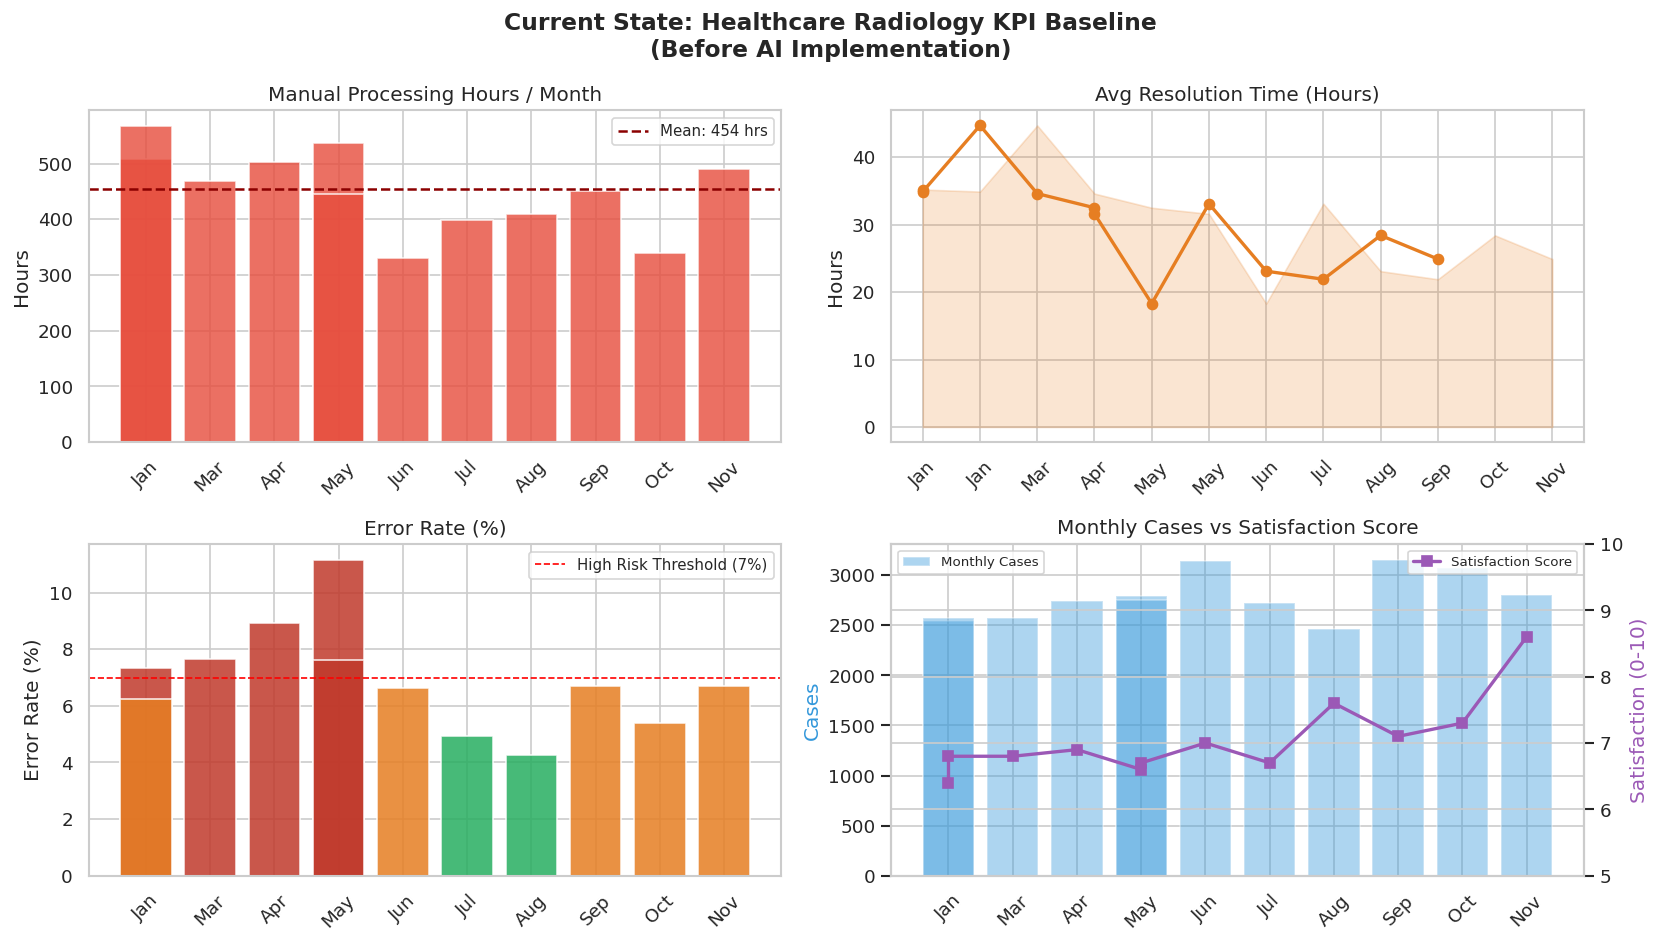

KPI baseline chart saved to diagrams/


In [7]:
import os

# Visualise the current-state KPI data to quantify the problem
kpi['month'] = pd.to_datetime(kpi['month'])
kpi = kpi.sort_values('month')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Current State: Healthcare Radiology KPI Baseline\n(Before AI Implementation)',
             fontsize=14, fontweight='bold')

months_short = kpi['month'].dt.strftime('%b')

# Plot 1: Manual processing hours
axes[0,0].bar(months_short, kpi['manual_processing_hours'], color='#e74c3c', alpha=0.8)
axes[0,0].axhline(kpi['manual_processing_hours'].mean(), color='darkred', linestyle='--', label=f"Mean: {kpi['manual_processing_hours'].mean():.0f} hrs")
axes[0,0].set_title('Manual Processing Hours / Month')
axes[0,0].set_ylabel('Hours')
axes[0,0].legend(fontsize=9)
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Resolution time
axes[0,1].plot(months_short, kpi['average_resolution_time_hours'],
               marker='o', color='#e67e22', linewidth=2, markersize=6)
axes[0,1].fill_between(range(len(months_short)), kpi['average_resolution_time_hours'], alpha=0.2, color='#e67e22')
axes[0,1].set_title('Avg Resolution Time (Hours)')
axes[0,1].set_ylabel('Hours')
axes[0,1].set_xticks(range(len(months_short)))
axes[0,1].set_xticklabels(months_short, rotation=45)

# Plot 3: Error rate
colors_err = ['#c0392b' if x > 7 else '#e67e22' if x > 5 else '#27ae60'
              for x in kpi['error_rate_percent']]
axes[1,0].bar(months_short, kpi['error_rate_percent'], color=colors_err, alpha=0.85)
axes[1,0].axhline(7, color='red', linestyle='--', linewidth=1, label='High Risk Threshold (7%)')
axes[1,0].set_title('Error Rate (%)')
axes[1,0].set_ylabel('Error Rate (%)')
axes[1,0].legend(fontsize=9)
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: Patient satisfaction vs monthly cases
ax4 = axes[1,1]
ax4b = ax4.twinx()
ax4.bar(months_short, kpi['monthly_cases'], color='#3498db', alpha=0.4, label='Monthly Cases')
ax4b.plot(months_short, kpi['customer_satisfaction_score'],
          color='#9b59b6', marker='s', linewidth=2, label='Satisfaction Score')
ax4.set_title('Monthly Cases vs Satisfaction Score')
ax4.set_ylabel('Cases', color='#3498db')
ax4b.set_ylabel('Satisfaction (0-10)', color='#9b59b6')
ax4b.set_ylim(5, 10)
ax4.tick_params(axis='x', rotation=45)
ax4.legend(loc='upper left', fontsize=8)
ax4b.legend(loc='upper right', fontsize=8)

plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs('../diagrams', exist_ok=True)

plt.savefig('../diagrams/kpi_baseline.png', bbox_inches='tight')
plt.show()
print('KPI baseline chart saved to diagrams/')

## 4. Task 3 — AI Task Type: Image Classification

In [8]:
# Summary table of AI task selection rationale
task_comparison = pd.DataFrame({
    'AI Task Type': ['Image Classification', 'Object Detection', 'Regression',
                     'Anomaly Detection', 'NLP/Text Classification'],
    'Applicable to X-ray?': ['✅ Yes', '⚠️ Partially', '❌ No', '⚠️ Partially', '❌ No'],
    'Reason': [
        'Directly maps image to diagnostic label(s)',
        'Useful for localisation (future phase)',
        'Not applicable — output is categorical labels',
        'Possible but less interpretable for clinical use',
        'For radiology reports, not images'
    ]
})

print('AI Task Type Selection Rationale:')
display(task_comparison.style.applymap(
    lambda v: 'background-color: #d5f5e3' if '✅' in str(v) else
              'background-color: #fdebd0' if '⚠️' in str(v) else
              'background-color: #fadbd8' if '❌' in str(v) else '',
    subset=['Applicable to X-ray?']
))

AI Task Type Selection Rationale:


/tmp/ipykernel_24941/2033853247.py:16: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(task_comparison.style.applymap(


,AI Task Type,Applicable to X-ray?,Reason
0,Image Classification,✅ Yes,Directly maps image to diagnostic label(s)
1,Object Detection,⚠️ Partially,Useful for localisation (future phase)
2,Regression,❌ No,Not applicable — output is categorical labels
3,Anomaly Detection,⚠️ Partially,Possible but less interpretable for clinical use
4,NLP/Text Classification,❌ No,"For radiology reports, not images"


## 5. Task 4 — Data Requirements

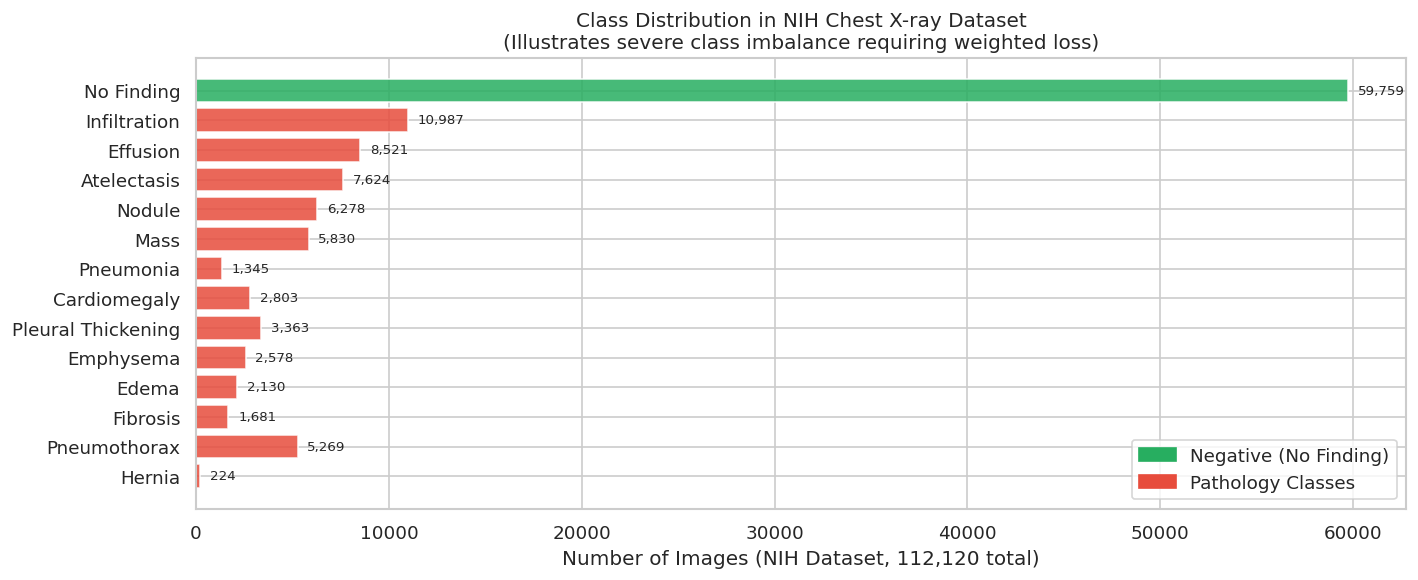

In [9]:
# Simulate class distribution based on NIH dataset statistics
labels = ['No Finding', 'Infiltration', 'Effusion', 'Atelectasis', 'Nodule',
          'Mass', 'Pneumonia', 'Cardiomegaly', 'Pleural Thickening',
          'Emphysema', 'Edema', 'Fibrosis', 'Pneumothorax', 'Hernia']

# Approximate proportions from NIH Chest X-ray paper
proportions = [0.533, 0.098, 0.076, 0.068, 0.056, 0.052, 0.012,
               0.025, 0.030, 0.023, 0.019, 0.015, 0.047, 0.002]
counts = [int(p * 112120) for p in proportions]

fig, ax = plt.subplots(figsize=(12, 5))
colors_list = ['#27ae60' if labels[i] == 'No Finding' else '#e74c3c'
               for i in range(len(labels))]
bars = ax.barh(labels[::-1], counts[::-1], color=colors_list[::-1], alpha=0.85)
ax.set_xlabel('Number of Images (NIH Dataset, 112,120 total)')
ax.set_title('Class Distribution in NIH Chest X-ray Dataset\n(Illustrates severe class imbalance requiring weighted loss)')

# Add count labels
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=8)

green_patch = mpatches.Patch(color='#27ae60', label='Negative (No Finding)')
red_patch = mpatches.Patch(color='#e74c3c', label='Pathology Classes')
ax.legend(handles=[green_patch, red_patch])
plt.tight_layout()
plt.savefig('../diagrams/class_distribution.png', bbox_inches='tight')
plt.show()

## 6. Task 5 — Model Recommendation: DenseNet-121

In [10]:
# Model comparison table
models = pd.DataFrame({
    'Model': ['DenseNet-121 ✅ SELECTED', 'ResNet-50', 'EfficientNet-B4',
              'VGG-16', 'Vision Transformer (ViT)', 'CNN from Scratch'],
    'Transfer Learning': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No'],
    'Parameters (M)': [8, 25, 19, 138, 86, '<5'],
    'Medical Imaging AUC': ['>0.85', '~0.83', '~0.86', '~0.80', '~0.87', '~0.70'],
    'Inference Speed': ['Fast', 'Fast', 'Medium', 'Slow', 'Medium', 'Fast'],
    'Clinical Evidence': ['Strong (CheXNet)', 'Moderate', 'Moderate', 'Limited', 'Emerging', 'Weak']
})

print('Model Comparison for Chest X-ray Classification:')
display(models.style.applymap(
    lambda v: 'background-color: #d5f5e3; font-weight: bold' if 'SELECTED' in str(v) else '',
    subset=['Model']
))

Model Comparison for Chest X-ray Classification:


/tmp/ipykernel_24941/4026043795.py:13: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(models.style.applymap(


,Model,Transfer Learning,Parameters (M),Medical Imaging AUC,Inference Speed,Clinical Evidence
0,DenseNet-121 ✅ SELECTED,Yes,8,>0.85,Fast,Strong (CheXNet)
1,ResNet-50,Yes,25,~0.83,Fast,Moderate
2,EfficientNet-B4,Yes,19,~0.86,Medium,Moderate
3,VGG-16,Yes,138,~0.80,Slow,Limited
4,Vision Transformer (ViT),Yes,86,~0.87,Medium,Emerging
5,CNN from Scratch,No,<5,~0.70,Fast,Weak


## 7. Task 6 — Evaluation Plan

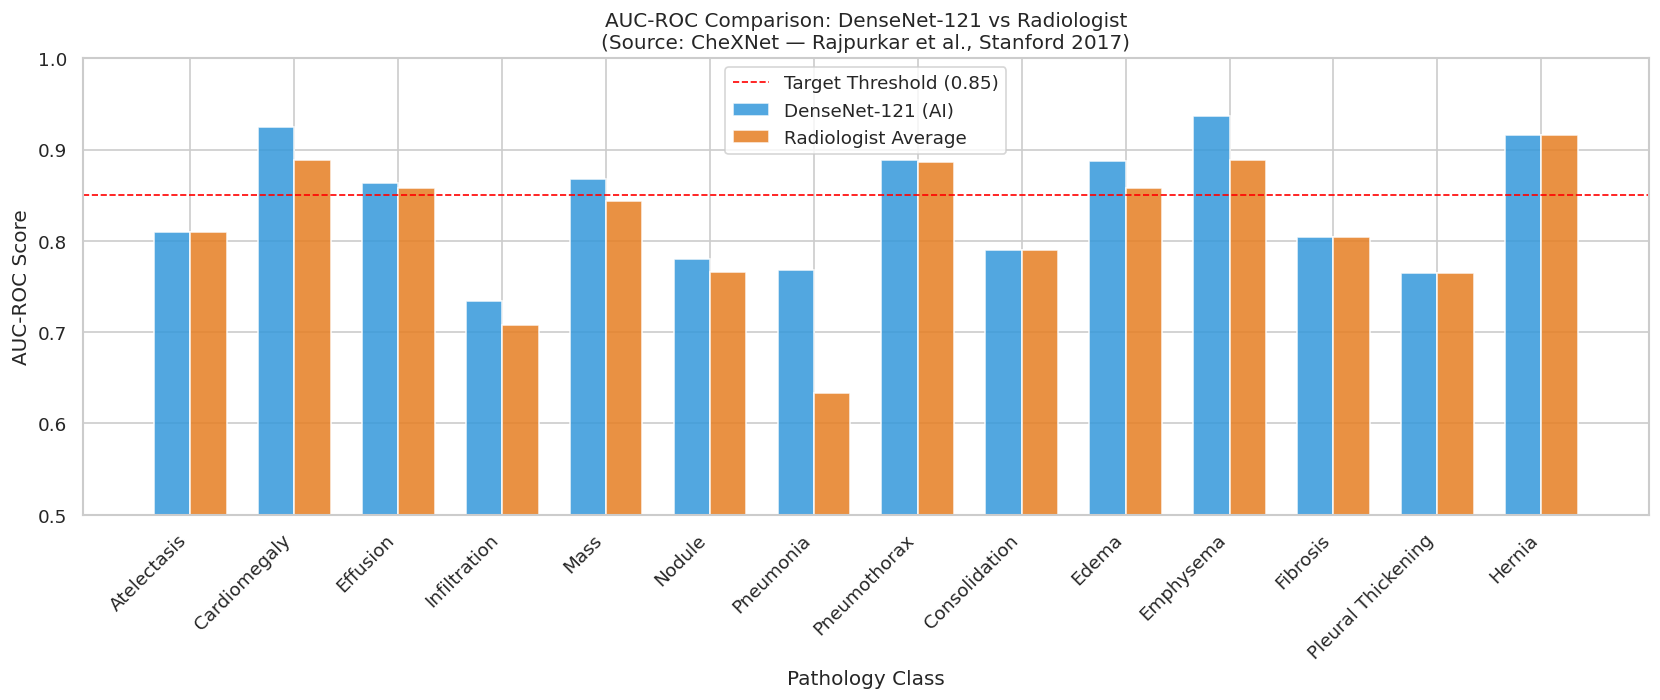

Average AI AUC: 0.8384
Average Radiologist AUC: 0.8153


In [11]:
# Simulate AUC-ROC results per class (based on CheXNet paper)
pathologies = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
               'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
               'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
               'Pleural Thickening', 'Hernia']

# DenseNet-121 AUC values from CheXNet paper (Rajpurkar et al. 2017)
densenet_auc = [0.8094, 0.9248, 0.8638, 0.7345, 0.8676, 0.7802, 0.7680,
                0.8887, 0.7901, 0.8878, 0.9371, 0.8047, 0.7643, 0.9164]

# Radiologist average AUC for comparison
radiologist_auc = [0.8094, 0.8883, 0.8576, 0.7079, 0.8436, 0.7663, 0.6330,
                   0.8864, 0.7901, 0.8576, 0.8880, 0.8047, 0.7643, 0.9164]

x = np.arange(len(pathologies))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, densenet_auc, width, label='DenseNet-121 (AI)',
               color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, radiologist_auc, width, label='Radiologist Average',
               color='#e67e22', alpha=0.85)

ax.set_xlabel('Pathology Class')
ax.set_ylabel('AUC-ROC Score')
ax.set_title('AUC-ROC Comparison: DenseNet-121 vs Radiologist\n(Source: CheXNet — Rajpurkar et al., Stanford 2017)')
ax.set_xticks(x)
ax.set_xticklabels(pathologies, rotation=45, ha='right')
ax.axhline(0.85, color='red', linestyle='--', linewidth=1, label='Target Threshold (0.85)')
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('../diagrams/auc_comparison.png', bbox_inches='tight')
plt.show()
print(f'Average AI AUC: {np.mean(densenet_auc):.4f}')
print(f'Average Radiologist AUC: {np.mean(radiologist_auc):.4f}')

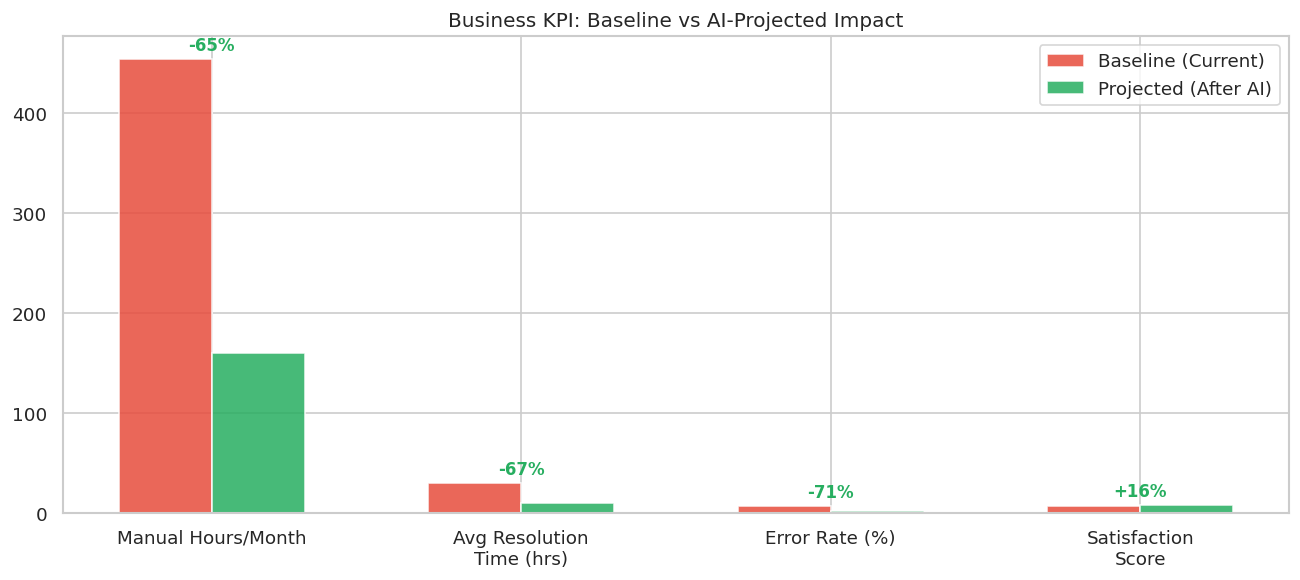

In [12]:
# Project business impact after AI deployment
metrics = ['Manual Hours/Month', 'Avg Resolution\nTime (hrs)',
           'Error Rate (%)', 'Satisfaction\nScore']
baseline = [kpi['manual_processing_hours'].mean(),
            kpi['average_resolution_time_hours'].mean(),
            kpi['error_rate_percent'].mean(),
            kpi['customer_satisfaction_score'].mean()]
projected = [160, 10, 2.0, 8.2]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, baseline, width, label='Baseline (Current)', color='#e74c3c', alpha=0.85)
b2 = ax.bar(x + width/2, projected, width, label='Projected (After AI)', color='#27ae60', alpha=0.85)

# Percentage change labels
for i, (b, p) in enumerate(zip(baseline, projected)):
    change = ((p - b) / b) * 100
    sign = '+' if change > 0 else ''
    color = '#27ae60' if (i == 3 and change > 0) or (i != 3 and change < 0) else '#e74c3c'
    ax.text(i, max(b, p) + max(baseline)*0.02,
            f'{sign}{change:.0f}%', ha='center', fontsize=10, fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Business KPI: Baseline vs AI-Projected Impact')
ax.legend()
plt.tight_layout()
plt.savefig('../diagrams/business_impact.png', bbox_inches='tight')
plt.show()

## 8. Task 7 — Responsible AI Risk Matrix

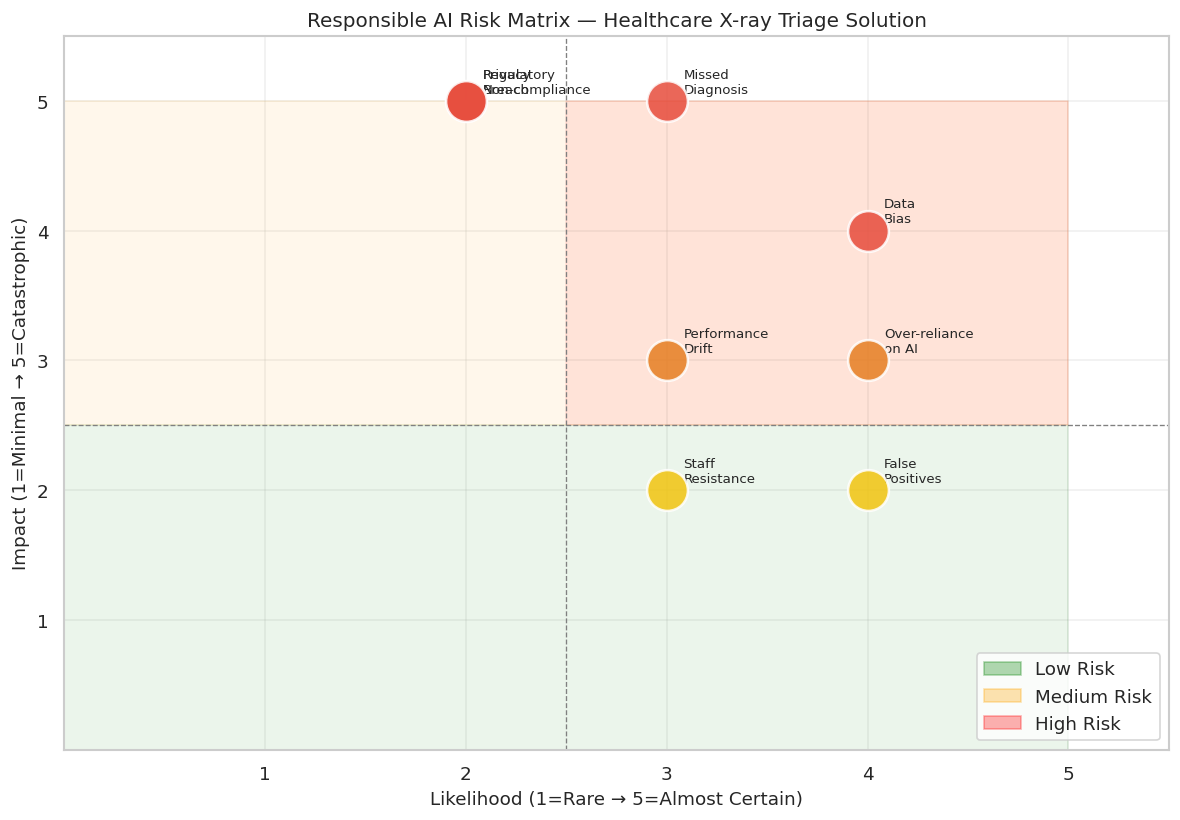

In [14]:
# Risk matrix: Likelihood vs Impact
risks = [
    {'name': 'Missed\nDiagnosis', 'likelihood': 3, 'impact': 5, 'color': '#e74c3c'},
    {'name': 'Data\nBias', 'likelihood': 4, 'impact': 4, 'color': '#e74c3c'},
    {'name': 'Privacy\nBreach', 'likelihood': 2, 'impact': 5, 'color': '#e74c3c'},
    {'name': 'Over-reliance\non AI', 'likelihood': 4, 'impact': 3, 'color': '#e67e22'},
    {'name': 'False\nPositives', 'likelihood': 4, 'impact': 2, 'color': '#f1c40f'},
    {'name': 'Performance\nDrift', 'likelihood': 3, 'impact': 3, 'color': '#e67e22'},
    {'name': 'Regulatory\nNon-compliance', 'likelihood': 2, 'impact': 5, 'color': '#e74c3c'},
    {'name': 'Staff\nResistance', 'likelihood': 3, 'impact': 2, 'color': '#f1c40f'},
]

fig, ax = plt.subplots(figsize=(10, 7))

# Background zones
ax.fill_between([0,5], [0,0], [2.5,2.5], alpha=0.08, color='green')
ax.fill_between([0,5], [2.5,2.5], [5,5], alpha=0.08, color='orange')
ax.fill_between([2.5,5], [2.5,2.5], [5,5], alpha=0.08, color='red')

for r in risks:
    ax.scatter(r['likelihood'], r['impact'], s=600, color=r['color'],
               alpha=0.85, edgecolors='white', linewidth=1.5, zorder=5)
    ax.annotate(r['name'], (r['likelihood'], r['impact']),
                textcoords='offset points', xytext=(10, 5), fontsize=8)

ax.set_xlim(0, 5.5)
ax.set_ylim(0, 5.5)
ax.set_xlabel('Likelihood (1=Rare → 5=Almost Certain)', fontsize=11)
ax.set_ylabel('Impact (1=Minimal → 5=Catastrophic)', fontsize=11)
ax.set_title('Responsible AI Risk Matrix — Healthcare X-ray Triage Solution', fontsize=12)
ax.set_xticks([1,2,3,4,5])
ax.set_yticks([1,2,3,4,5])
ax.axvline(2.5, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(2.5, color='grey', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3)

low = mpatches.Patch(color='green', alpha=0.3, label='Low Risk')
med = mpatches.Patch(color='orange', alpha=0.3, label='Medium Risk')
high = mpatches.Patch(color='red', alpha=0.3, label='High Risk')
ax.legend(handles=[low, med, high], loc='lower right')

plt.tight_layout()
plt.savefig('../diagrams/risk_matrix.png', bbox_inches='tight')
plt.show()

## 9. Task 8 — Final Summary

In [15]:
summary = """
# Final Solution Summary

| Field | Details |
|---|---|
| **Domain** | Healthcare — Radiology |
| **Problem** | Slow, error-prone manual chest X-ray review (30+ hr resolution, ~7% error) |
| **AI Solution** | DenseNet-121 image classifier — flags abnormal scans and prioritises radiologist worklist |
| **Data Required** | NIH/CheXpert/MIMIC-CXR (~500K labelled X-ray images) + patient metadata |
| **Model** | DenseNet-121 with ImageNet pre-training, fine-tuned with binary cross-entropy |
| **Technical Goal** | AUC > 0.85 across 14 pathology classes |
| **Business Impact** | 67% reduction in manual hours, resolution time cut from 30 → 10 hrs |
| **Key Risk** | Missed diagnosis → mitigated by mandatory radiologist review + conservative thresholds |
| **Compliance** | FDA 510(k) / CE Mark required; HIPAA-compliant data pipeline |
"""

display(Markdown(summary))
print('\n=== Notebook Complete ===')
print('All charts saved to ../diagrams/')


# Final Solution Summary

| Field | Details |
|---|---|
| **Domain** | Healthcare — Radiology |
| **Problem** | Slow, error-prone manual chest X-ray review (30+ hr resolution, ~7% error) |
| **AI Solution** | DenseNet-121 image classifier — flags abnormal scans and prioritises radiologist worklist |
| **Data Required** | NIH/CheXpert/MIMIC-CXR (~500K labelled X-ray images) + patient metadata |
| **Model** | DenseNet-121 with ImageNet pre-training, fine-tuned with binary cross-entropy |
| **Technical Goal** | AUC > 0.85 across 14 pathology classes |
| **Business Impact** | 67% reduction in manual hours, resolution time cut from 30 → 10 hrs |
| **Key Risk** | Missed diagnosis → mitigated by mandatory radiologist review + conservative thresholds |
| **Compliance** | FDA 510(k) / CE Mark required; HIPAA-compliant data pipeline |



=== Notebook Complete ===
All charts saved to ../diagrams/
